# 1. Install Dependencies

In [ ]:
!pip install datasets snntorch torchvision codecarbon torchinfo -q

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from datasets import load_dataset
from torchvision import transforms
import torchvision.models as models
from torch.utils.data import DataLoader, random_split
from PIL import Image
import io
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import Counter
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import snntorch as snn
from snntorch import surrogate
from torchinfo import summary as torchinfo_summary
from codecarbon import EmissionsTracker

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Using CPU")

results        = []
energy_results = []

# 2. Dataset Loading

In [ ]:
print("Loading 1000Samples dataset...")
ds_1000 = load_dataset("Ankhitan/1000Samples")
print(ds_1000)

print("\nLoading AI4Mars dataset...")
ds_ai4mars = load_dataset("hassanjbara/AI4MARS")
print(ds_ai4mars)

## Dataset A: 1000Samples


In [ ]:
class TerrainDataset1000(torch.utils.data.Dataset):
    def __init__(self, hf_dataset, transform):
        self.data = []
        for item in hf_dataset:
            try:
                img_bytes = item['pixel_values']['bytes']
                label = item['label.annotations'][0]['category_id']
                if label in [1, 2, 3]:   # soil, bedrock, sand
                    self.data.append((img_bytes, label - 1))
            except:
                pass
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_bytes, label = self.data[idx]
        image = Image.open(io.BytesIO(img_bytes)).convert("L")
        return self.transform(image), label

# Preprocessing A1 — minimal (grayscale + resize + normalize)
transform_a1 = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Preprocessing A2 — augmented (flip + rotation + contrast)
transform_a2 = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

NUM_CLASSES_A = 3
CLASSES_A = ['Soil', 'Bedrock', 'Sand']

full_a1 = TerrainDataset1000(ds_1000['train'], transform_a1)
full_a2 = TerrainDataset1000(ds_1000['train'], transform_a2)

def split_dataset(dataset, ratio=0.8):
    n_train = int(len(dataset) * ratio)
    n_test  = len(dataset) - n_train
    return random_split(dataset, [n_train, n_test],
                        generator=torch.Generator().manual_seed(seed))

train_a1, test_a1 = split_dataset(full_a1)
train_a2, test_a2 = split_dataset(full_a2)

loader_train_a1 = DataLoader(train_a1, batch_size=32, shuffle=True)
loader_test_a1  = DataLoader(test_a1,  batch_size=32, shuffle=False)
loader_train_a2 = DataLoader(train_a2, batch_size=32, shuffle=True)
loader_test_a2  = DataLoader(test_a2,  batch_size=32, shuffle=False)

all_labels = [full_a1[i][1] for i in range(len(full_a1))]
print("1000Samples class distribution:", Counter(all_labels))
print(f"Train: {len(train_a1)}  |  Test: {len(test_a1)}")

1000Samples class distribution: Counter({2: 385, 1: 287, 0: 260})
Train: 745  |  Test: 187


## Dataset B: AI4Mars

In [ ]:
class AI4MarsDataset(torch.utils.data.Dataset):
    def __init__(self, hf_dataset, transform, max_samples=5000):
        self.transform = transform
        self.data = []
        remap = {0: 0, 1: 1, 2: 2}
        count = 0
        for item in hf_dataset:
            if count >= max_samples:
                break
            try:
                if not item.get('has_labels'):
                    continue
                mask = item['label_mask']
                if mask is None:
                    continue
                mask_arr = np.array(mask)
                valid = mask_arr[mask_arr <= 2]
                if len(valid) < 100:
                    continue
                label = int(np.bincount(valid).argmax())
                img = item['image'].convert("L")
                self.data.append((img, label))
                count += 1
            except:
                pass
        print(f"  Loaded {len(self.data)} usable AI4Mars samples")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img, label = self.data[idx]
        return self.transform(img), label

# Preprocessing B1 — minimal
transform_b1 = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Preprocessing B2 — augmented + contrast enhancement
transform_b2 = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.4, contrast=0.5),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

NUM_CLASSES_B = 3
CLASSES_B = ['Soil', 'Bedrock', 'Sand']

print("Building AI4Mars-B1...")
full_b1 = AI4MarsDataset(ds_ai4mars['train'], transform_b1, max_samples=5000)
print("Building AI4Mars-B2...")
full_b2 = AI4MarsDataset(ds_ai4mars['train'], transform_b2, max_samples=5000)

train_b1, test_b1 = split_dataset(full_b1)
train_b2, test_b2 = split_dataset(full_b2)

loader_train_b1 = DataLoader(train_b1, batch_size=32, shuffle=True)
loader_test_b1  = DataLoader(test_b1,  batch_size=32, shuffle=False)
loader_train_b2 = DataLoader(train_b2, batch_size=32, shuffle=True)
loader_test_b2  = DataLoader(test_b2,  batch_size=32, shuffle=False)

all_labels_b = [full_b1[i][1] for i in range(len(full_b1))]
print("AI4Mars class distribution:", Counter(all_labels_b))
print(f"Train: {len(train_b1)}  |  Test: {len(test_b1)}")

Building AI4Mars-B1...
  Loaded 5000 usable AI4Mars samples
Building AI4Mars-B2...
  Loaded 5000 usable AI4Mars samples
AI4Mars class distribution: Counter({1: 2658, 0: 1750, 2: 592})
Train: 4000  |  Test: 1000


# 3. Sample Visualization

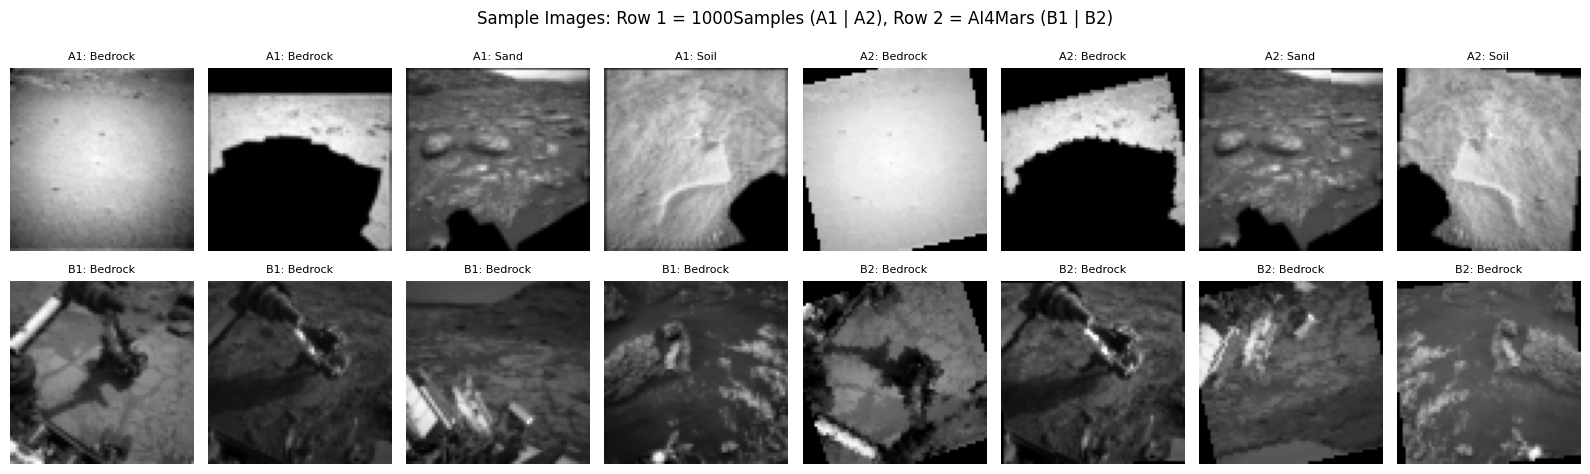

In [ ]:
fig, axes = plt.subplots(2, 8, figsize=(16, 5))
fig.suptitle("Sample Images: Row 1 = 1000Samples (A1 | A2), Row 2 = AI4Mars (B1 | B2)", fontsize=12)

for col in range(4):
    img_a1, lbl_a1 = full_a1[col * 50]
    img_a2, lbl_a2 = full_a2[col * 50]
    axes[0, col].imshow(img_a1.squeeze(), cmap='gray')
    axes[0, col].set_title(f"A1: {CLASSES_A[lbl_a1]}", fontsize=8)
    axes[0, col].axis('off')
    axes[0, col+4].imshow(img_a2.squeeze(), cmap='gray')
    axes[0, col+4].set_title(f"A2: {CLASSES_A[lbl_a2]}", fontsize=8)
    axes[0, col+4].axis('off')

for col in range(4):
    img_b1, lbl_b1 = full_b1[col * 100]
    img_b2, lbl_b2 = full_b2[col * 100]
    axes[1, col].imshow(img_b1.squeeze(), cmap='gray')
    axes[1, col].set_title(f"B1: {CLASSES_B[lbl_b1]}", fontsize=8)
    axes[1, col].axis('off')
    axes[1, col+4].imshow(img_b2.squeeze(), cmap='gray')
    axes[1, col+4].set_title(f"B2: {CLASSES_B[lbl_b2]}", fontsize=8)
    axes[1, col+4].axis('off')

plt.tight_layout()
plt.show()

# 4. Helper Functions

In [ ]:
def train_model(model, loader, criterion, optimizer, epochs=10, label=""):
    model.train()
    loss_history = []
    start = time.time()
    for epoch in range(epochs):
        total_loss = 0
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        loss_history.append(total_loss)
        print(f"  [{label}] Epoch [{epoch+1}/{epochs}], Loss: {total_loss:.4f}")
    elapsed = time.time() - start
    print(f"  Training time: {elapsed:.2f}s")
    return elapsed, loss_history

def evaluate_model(model, loader):
    model.eval()
    correct = 0
    total   = 0
    all_preds   = []
    all_targets = []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total   += labels.size(0)
            correct += (predicted == labels).sum().item()
            all_preds.extend(predicted.cpu().numpy())
            all_targets.extend(labels.cpu().numpy())
    accuracy = 100 * correct / total
    return accuracy, all_preds, all_targets

def measure_inference(model, loader):
    model.eval()
    images, _ = next(iter(loader))
    images = images.to(device)
    with torch.no_grad(): _ = model(images)
    start = time.time()
    with torch.no_grad(): _ = model(images)
    elapsed    = (time.time() - start) * 1000
    per_image  = elapsed / images.shape[0]
    return elapsed, per_image

ENERGY_PER_MAC = {
    "GPU (T4)":  0.30,
    "CPU":       8.60,
    "ARM":       0.90,
    "Loihi":     0.02711,
}

def count_macs(model, input_size=(1, 1, 64, 64)):
    """Count multiply-accumulate operations using torchinfo."""
    try:
        s = torchinfo_summary(model, input_size=input_size,
                              verbose=0, device=device)
        return s.total_mult_adds
    except Exception as e:
        print(f"    MAC count warning: {e}")
        return None

def measure_snn_spike_rate(model, loader, num_steps=25):
    model.eval()
    spike_rates = []
    images, _ = next(iter(loader))
    images = images.to(device)

    spk_outputs = []
    hooks = []
    for module in model.modules():
        if isinstance(module, snn.Leaky):
            def hook_fn(m, inp, out):
                spk = out[0] if isinstance(out, tuple) else out
                spk_outputs.append(spk.detach().cpu())
            hooks.append(module.register_forward_hook(hook_fn))

    with torch.no_grad():
        _ = model(images)

    for h in hooks:
        h.remove()

    if spk_outputs:
        all_spikes = torch.cat([s.flatten() for s in spk_outputs])
        mean_rate  = all_spikes.float().mean().item()
        return mean_rate
    return 1.0

def compute_mac_energy(model, loader, model_name, exp_name, input_size=(1,1,64,64)):
    macs = count_macs(model, input_size=input_size)
    if macs is None:
        print("    Could not count MACs — skipping energy estimate.")
        return {}

    spike_rate = 1.0
    is_snn = isinstance(model, SpikingNet)
    if is_snn:
        spike_rate = measure_snn_spike_rate(model, loader)
        print(f"    SNN mean spike rate: {spike_rate:.4f}  "
              f"({'sparse ✓' if spike_rate < 0.3 else 'dense'})")

    energy_dict = {}
    print(f"    MACs: {macs:,}")
    print(f"    {'Hardware':<15} {'MACs (eff.)':<15} {'Energy (μJ)':<15}")
    print(f"    {'-'*45}")
    for hw, nj_per_mac in ENERGY_PER_MAC.items():
        effective_macs = macs * (spike_rate if is_snn else 1.0)
        energy_nj = effective_macs * nj_per_mac
        energy_uj = energy_nj / 1000.0
        energy_dict[hw] = round(energy_uj, 6)
        print(f"    {hw:<15} {effective_macs:<15,.0f} {energy_uj:<15.4f} μJ")

    return energy_dict

def measure_codecarbon_energy(model, loader, n_batches=10):
    model.eval()
    images, _ = next(iter(loader))
    images = images.to(device)
    n_images = images.shape[0] * n_batches

    try:
        tracker = EmissionsTracker(
            project_name    = "rover_terrain",
            measure_power_secs = 1,
            log_level       = "error",
            save_to_file    = False,
        )
        tracker.start()

        with torch.no_grad():
            for _ in range(n_batches):
                _ = model(images)

        emissions_obj = tracker.stop()

        kwh_total     = tracker._total_energy.kWh
        co2_kg        = emissions_obj if emissions_obj else 0.0
        kwh_per_image = kwh_total / n_images
        co2_g_per_img = (co2_kg * 1000) / n_images

        print(f"    CodeCarbon: {kwh_total*1e9:.4f} nWh total  |  "
              f"{kwh_per_image*1e9:.6f} nWh/image  |  "
              f"{co2_g_per_img*1e6:.4f} μg CO₂/image")

        return kwh_total, kwh_per_image, co2_g_per_img

    except Exception as e:
        print(f"    CodeCarbon warning: {e}")
        t_start = time.time()
        with torch.no_grad():
            for _ in range(n_batches):
                _ = model(images)
        t_elapsed = time.time() - t_start
        tdp_w      = 70.0
        joules     = tdp_w * t_elapsed * 0.3
        kwh_total  = joules / 3_600_000
        kwh_per_img = kwh_total / n_images
        co2_g      = kwh_per_img * 0.386 * 1000
        print(f"    Fallback estimate: {kwh_total*1e9:.4f} nWh total  |  "
              f"{kwh_per_img*1e9:.6f} nWh/image")
        return kwh_total, kwh_per_img, co2_g

def record(exp, model_name, model, accuracy, train_time, test_loader):
    batch_ms, per_ms = measure_inference(model, test_loader)
    num_params = sum(p.numel() for p in model.parameters())

    print(f"  --- Energy Analysis: {model_name} ---")
    mac_energy = compute_mac_energy(model, test_loader,
                                    model_name, exp, input_size=(1,1,64,64))

    print(f"  Running CodeCarbon measurement...")
    kwh_total, kwh_per_img, co2_g = measure_codecarbon_energy(model, test_loader)

    results.append({
        "Experiment":            exp,
        "Model":                 model_name,
        "Accuracy (%)":          round(accuracy, 2),
        "Params":                num_params,
        "Train Time (s)":        round(train_time, 2),
        "Inference/img (ms)":    round(per_ms, 4),
    })

    row = {
        "Experiment":            exp,
        "Model":                 model_name,
        "MACs":                  count_macs(model, input_size=(1,1,64,64)),
        "CC_nWh_per_img":        round(kwh_per_img * 1e9, 6),
        "CC_ugCO2_per_img":      round(co2_g * 1e6, 6),
    }
    for hw, uj in mac_energy.items():
        row[f"MAC_{hw}_uJ"] = uj
    energy_results.append(row)

    print(f"  Accuracy: {accuracy:.2f}% | Params: {num_params:,} | "
          f"Inference: {per_ms:.4f} ms/img")

print("Helper functions defined (with energy measurement).")

Helper functions defined (with energy measurement).


# 5. Models

In [ ]:
class TinyCNN(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
    def forward(self, x):
        return self.fc(self.conv(x))

def build_mobilenet(num_classes=3):
    model = models.mobilenet_v2(weights="DEFAULT")
    model.features[0][0] = nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1, bias=False)
    model.classifier[1] = nn.Linear(model.last_channel, num_classes)
    return model

class SpikingNet(nn.Module):
    def __init__(self, num_classes=3, num_steps=25, beta=0.85):
        super().__init__()
        self.num_steps = num_steps
        spike_grad = surrogate.fast_sigmoid(slope=25)

        self.features = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.fc1   = nn.Linear(32 * 16 * 16, 256)
        self.lif1  = snn.Leaky(beta=beta, spike_grad=spike_grad, learn_beta=True)
        self.fc2   = nn.Linear(256, 128)
        self.lif2  = snn.Leaky(beta=beta, spike_grad=spike_grad, learn_beta=True)
        self.fc3   = nn.Linear(128, num_classes)
        self.lif3  = snn.Leaky(beta=beta, spike_grad=spike_grad, learn_beta=True)

    def forward(self, x):
        feat = self.features(x)
        feat = feat.view(feat.size(0), -1)

        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()
        mem3 = self.lif3.init_leaky()
        spk3_sum = torch.zeros(x.size(0), self.fc3.out_features, device=x.device)

        for _ in range(self.num_steps):
            cur1 = self.fc1(feat)
            spk1, mem1 = self.lif1(cur1, mem1)
            cur2 = self.fc2(spk1)
            spk2, mem2 = self.lif2(cur2, mem2)
            cur3 = self.fc3(spk2)
            spk3, mem3 = self.lif3(cur3, mem3)
            spk3_sum += spk3

        return spk3_sum

print("Model definitions ready.")
print(f"TinyCNN params:   {sum(p.numel() for p in TinyCNN().parameters()):,}")
print(f"MobileNetV2 params: {sum(p.numel() for p in build_mobilenet().parameters()):,}")
print(f"SpikingNet params:  {sum(p.numel() for p in SpikingNet().parameters()):,}")

Model definitions ready.
TinyCNN params:   1,073,123
Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 87.3MB/s]


MobileNetV2 params: 2,227,139
SpikingNet params:  2,135,590


In [ ]:
def run_experiment(exp_name, num_classes, class_names,
                   train_loader, test_loader, epochs=10):

    print(f"\n{'='*60}")
    print(f"EXPERIMENT: {exp_name}  |  classes={num_classes}  |  epochs={epochs}")
    print('='*60)

    loss_curves    = {}
    confusion_data = {}

    print("\n[1/3] Tiny CNN")
    cnn = TinyCNN(num_classes).to(device)
    opt = optim.Adam(cnn.parameters(), lr=1e-3, weight_decay=1e-4)
    sched = optim.lr_scheduler.StepLR(opt, step_size=5, gamma=0.5)
    elapsed, losses = train_model(cnn, train_loader, nn.CrossEntropyLoss(),
                                  opt, epochs=epochs, label="TinyCNN")
    for _ in range(epochs): sched.step()
    acc, preds, targets = evaluate_model(cnn, test_loader)
    record(exp_name, "Tiny CNN", cnn, acc, elapsed, test_loader)
    loss_curves["Tiny CNN"]    = losses
    confusion_data["Tiny CNN"] = (targets, preds)

    print("\n[2/3] MobileNetV2")
    mob = build_mobilenet(num_classes).to(device)
    opt_mob = optim.Adam([
        {'params': mob.features.parameters(),    'lr': 1e-4},
        {'params': mob.classifier.parameters(),  'lr': 1e-3}
    ], weight_decay=1e-4)
    sched_mob = optim.lr_scheduler.CosineAnnealingLR(opt_mob, T_max=epochs)
    elapsed_m, losses_m = train_model(mob, train_loader, nn.CrossEntropyLoss(),
                                      opt_mob, epochs=epochs, label="MobileNet")
    for _ in range(epochs): sched_mob.step()
    acc_m, preds_m, targets_m = evaluate_model(mob, test_loader)
    record(exp_name, "MobileNet", mob, acc_m, elapsed_m, test_loader)
    loss_curves["MobileNet"]    = losses_m
    confusion_data["MobileNet"] = (targets_m, preds_m)

    print("\n[3/3] SNN")
    spiking = SpikingNet(num_classes).to(device)
    opt_snn = optim.Adam(spiking.parameters(), lr=5e-4, weight_decay=1e-4)
    sched_snn = optim.lr_scheduler.OneCycleLR(
        opt_snn, max_lr=5e-4,
        steps_per_epoch=len(train_loader), epochs=epochs)
    elapsed_s, losses_s = train_model(spiking, train_loader, nn.CrossEntropyLoss(),
                                      opt_snn, epochs=epochs, label="SNN")
    acc_s, preds_s, targets_s = evaluate_model(spiking, test_loader)
    record(exp_name, "SNN", spiking, acc_s, elapsed_s, test_loader)
    loss_curves["SNN"]    = losses_s
    confusion_data["SNN"] = (targets_s, preds_s)

    plt.figure(figsize=(8, 4))
    for name, lc in loss_curves.items():
        plt.plot(range(1, len(lc)+1), lc, marker='o', label=name)
    plt.title(f"Training Loss — {exp_name}")
    plt.xlabel("Epoch"); plt.ylabel("Total Loss")
    plt.legend(); plt.grid(True)
    plt.tight_layout(); plt.show()

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(f"Confusion Matrices — {exp_name}", fontsize=13)
    for ax, (mname, (tgts, pds)) in zip(axes, confusion_data.items()):
        cm = confusion_matrix(tgts, pds)
        disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
        disp.plot(ax=ax, colorbar=False)
        ax.set_title(mname)
    plt.tight_layout(); plt.show()

    return loss_curves, confusion_data

print("run_experiment() helper ready.")

run_experiment() helper ready.


# 6. Experiments

## Experiment 1: 1000Samples, Preprocessing A1 (Minimal)


EXPERIMENT: 1000Samples | Prep-A1 (Minimal)  |  classes=3  |  epochs=10

[1/3] Tiny CNN
  [TinyCNN] Epoch [1/10], Loss: 27.8358
  [TinyCNN] Epoch [2/10], Loss: 18.5190
  [TinyCNN] Epoch [3/10], Loss: 16.5802
  [TinyCNN] Epoch [4/10], Loss: 16.2052
  [TinyCNN] Epoch [5/10], Loss: 15.0629
  [TinyCNN] Epoch [6/10], Loss: 13.2786
  [TinyCNN] Epoch [7/10], Loss: 13.4516
  [TinyCNN] Epoch [8/10], Loss: 13.8394
  [TinyCNN] Epoch [9/10], Loss: 13.8623
  [TinyCNN] Epoch [10/10], Loss: 12.6749
  Training time: 28.02s


[codecarbon WARNING @ 23:59:46] Multiple instances of codecarbon are allowed to run at the same time.


  --- Energy Analysis: Tiny CNN ---
    MACs: 11,191,523
    Hardware        MACs (eff.)     Energy (μJ)    
    ---------------------------------------------
    GPU (T4)        11,191,523      3357.4569       μJ
    CPU             11,191,523      96247.0978      μJ
    ARM             11,191,523      10072.3707      μJ
    Loihi           11,191,523      303.4022        μJ
  Running CodeCarbon measurement...
    CodeCarbon: 2927.9853 nWh total  |  9.149954 nWh/image  |  2.6123 μg CO₂/image
  Accuracy: 73.26% | Params: 1,073,123 | Inference: 0.3669 ms/img

[2/3] MobileNetV2
  [MobileNet] Epoch [1/10], Loss: 23.5728
  [MobileNet] Epoch [2/10], Loss: 17.0199
  [MobileNet] Epoch [3/10], Loss: 14.1748
  [MobileNet] Epoch [4/10], Loss: 11.9382
  [MobileNet] Epoch [5/10], Loss: 9.5919
  [MobileNet] Epoch [6/10], Loss: 8.7475
  [MobileNet] Epoch [7/10], Loss: 6.8679
  [MobileNet] Epoch [8/10], Loss: 6.6880
  [MobileNet] Epoch [9/10], Loss: 6.5490
  [MobileNet] Epoch [10/10], Loss: 5.2722
  

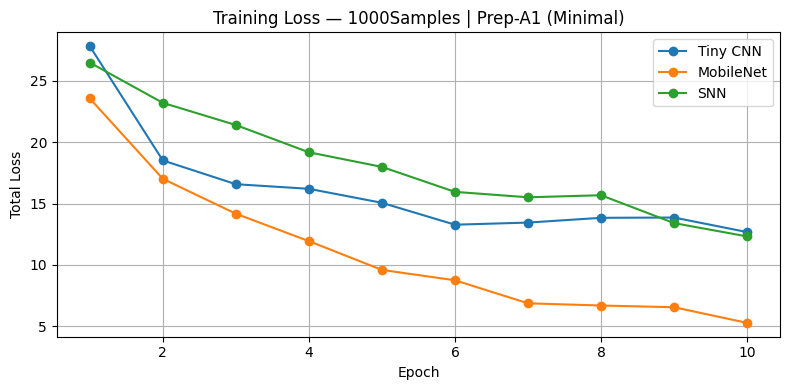

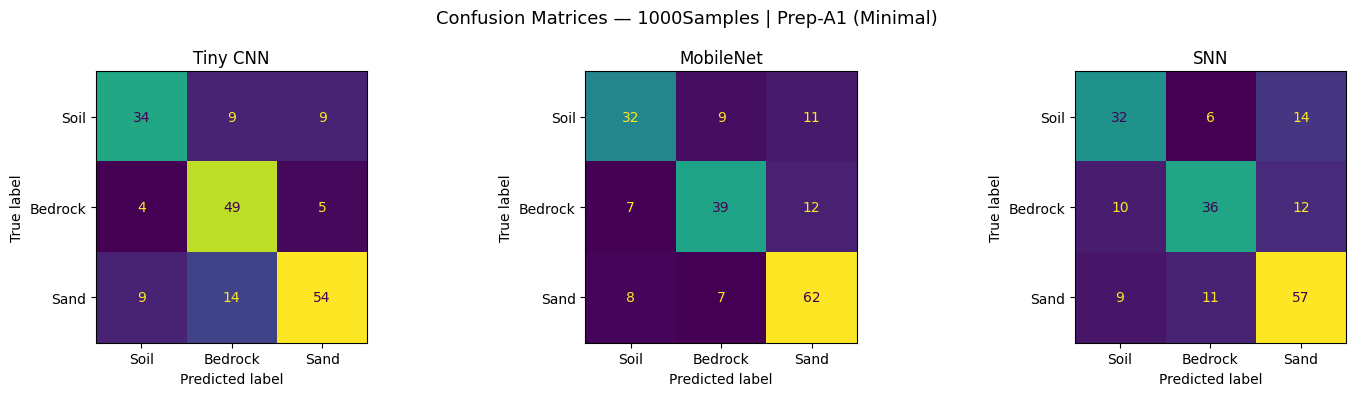

In [ ]:
lc1, cm1 = run_experiment(
    exp_name     = "1000Samples | Prep-A1 (Minimal)",
    num_classes  = NUM_CLASSES_A,
    class_names  = CLASSES_A,
    train_loader = loader_train_a1,
    test_loader  = loader_test_a1,
    epochs       = 10
)

## Experiment 2: 1000Samples, Preprocessing A2 (Augmented)


EXPERIMENT: 1000Samples | Prep-A2 (Augmented)  |  classes=3  |  epochs=10

[1/3] Tiny CNN
  [TinyCNN] Epoch [1/10], Loss: 34.7190
  [TinyCNN] Epoch [2/10], Loss: 21.2515
  [TinyCNN] Epoch [3/10], Loss: 19.4529
  [TinyCNN] Epoch [4/10], Loss: 18.8610
  [TinyCNN] Epoch [5/10], Loss: 19.4161
  [TinyCNN] Epoch [6/10], Loss: 17.5255
  [TinyCNN] Epoch [7/10], Loss: 18.4935
  [TinyCNN] Epoch [8/10], Loss: 17.7518
  [TinyCNN] Epoch [9/10], Loss: 16.7317
  [TinyCNN] Epoch [10/10], Loss: 16.7370
  Training time: 31.20s
  --- Energy Analysis: Tiny CNN ---
    MACs: 11,191,523
    Hardware        MACs (eff.)     Energy (μJ)    
    ---------------------------------------------
    GPU (T4)        11,191,523      3357.4569       μJ
    CPU             11,191,523      96247.0978      μJ
    ARM             11,191,523      10072.3707      μJ
    Loihi           11,191,523      303.4022        μJ
  Running CodeCarbon measurement...
    CodeCarbon: 2157.6000 nWh total  |  6.742500 nWh/image  |  1.9250

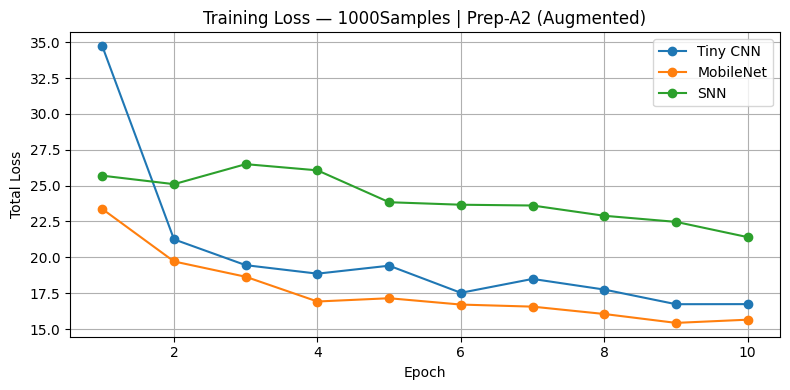

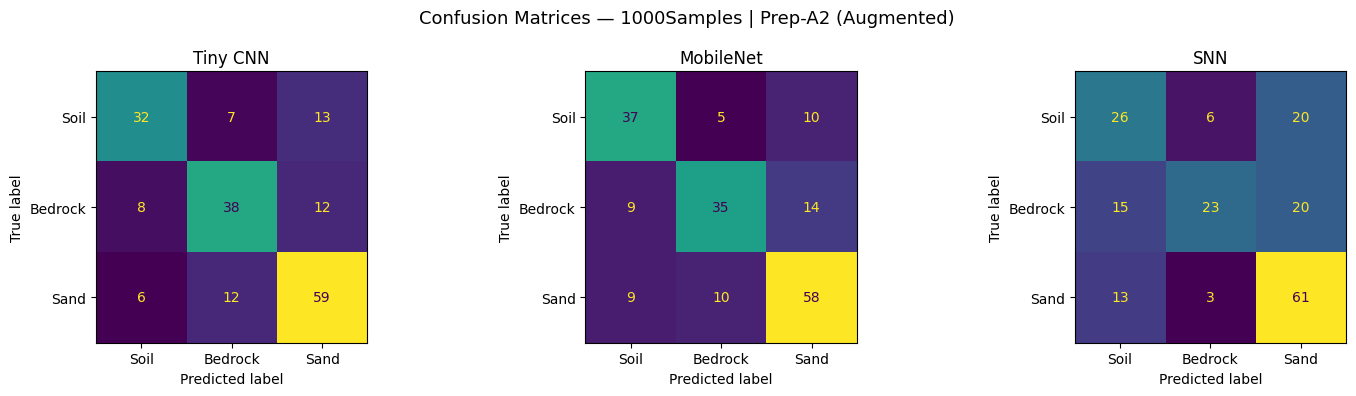

In [ ]:
lc2, cm2 = run_experiment(
    exp_name     = "1000Samples | Prep-A2 (Augmented)",
    num_classes  = NUM_CLASSES_A,
    class_names  = CLASSES_A,
    train_loader = loader_train_a2,
    test_loader  = loader_test_a2,
    epochs       = 10
)

## Experiment 3: AI4Mars, Preprocessing B1 (Minimal)


EXPERIMENT: AI4Mars | Prep-B1 (Minimal)  |  classes=3  |  epochs=10

[1/3] Tiny CNN
  [TinyCNN] Epoch [1/10], Loss: 115.0803
  [TinyCNN] Epoch [2/10], Loss: 85.3369
  [TinyCNN] Epoch [3/10], Loss: 77.5569
  [TinyCNN] Epoch [4/10], Loss: 71.4613
  [TinyCNN] Epoch [5/10], Loss: 64.7792
  [TinyCNN] Epoch [6/10], Loss: 63.1690
  [TinyCNN] Epoch [7/10], Loss: 59.4993
  [TinyCNN] Epoch [8/10], Loss: 57.7799
  [TinyCNN] Epoch [9/10], Loss: 51.9044
  [TinyCNN] Epoch [10/10], Loss: 50.2773
  Training time: 148.79s
  --- Energy Analysis: Tiny CNN ---
    MACs: 11,191,523
    Hardware        MACs (eff.)     Energy (μJ)    
    ---------------------------------------------
    GPU (T4)        11,191,523      3357.4569       μJ
    CPU             11,191,523      96247.0978      μJ
    ARM             11,191,523      10072.3707      μJ
    Loihi           11,191,523      303.4022        μJ
  Running CodeCarbon measurement...
    CodeCarbon: 2277.2032 nWh total  |  7.116260 nWh/image  |  2.0317 μg 

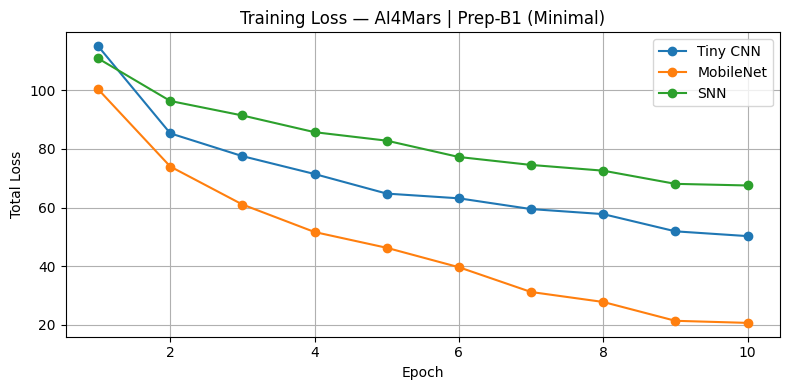

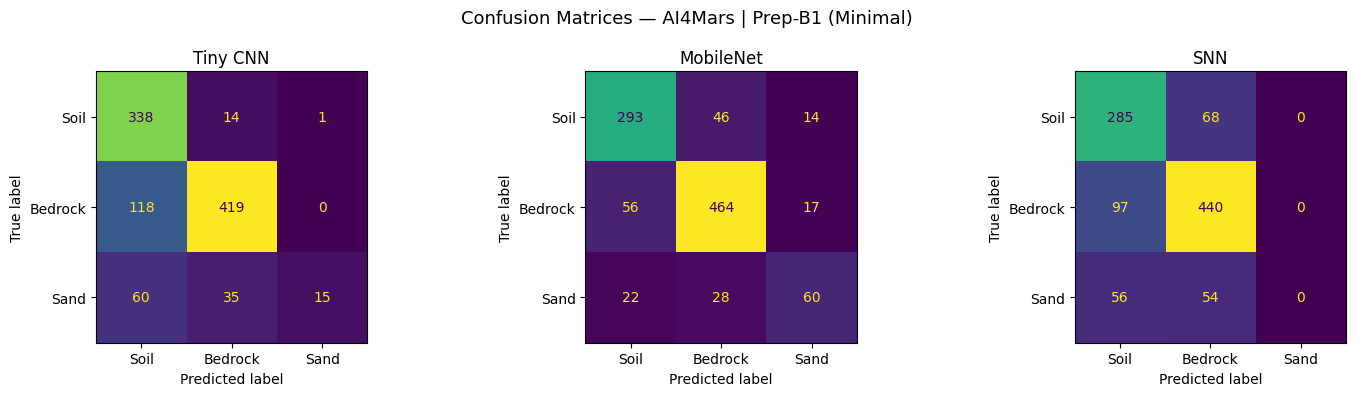

In [ ]:
lc3, cm3 = run_experiment(
    exp_name     = "AI4Mars | Prep-B1 (Minimal)",
    num_classes  = NUM_CLASSES_B,
    class_names  = CLASSES_B,
    train_loader = loader_train_b1,
    test_loader  = loader_test_b1,
    epochs       = 10
)

## Experiment 4: AI4Mars, Preprocessing B2 (Augmented)


EXPERIMENT: AI4Mars | Prep-B2 (Augmented)  |  classes=3  |  epochs=10

[1/3] Tiny CNN
  [TinyCNN] Epoch [1/10], Loss: 122.2932
  [TinyCNN] Epoch [2/10], Loss: 102.2865
  [TinyCNN] Epoch [3/10], Loss: 95.5077
  [TinyCNN] Epoch [4/10], Loss: 94.4382
  [TinyCNN] Epoch [5/10], Loss: 88.2625
  [TinyCNN] Epoch [6/10], Loss: 86.8926
  [TinyCNN] Epoch [7/10], Loss: 82.5507
  [TinyCNN] Epoch [8/10], Loss: 82.5517
  [TinyCNN] Epoch [9/10], Loss: 80.8302
  [TinyCNN] Epoch [10/10], Loss: 79.5388
  Training time: 159.37s
  --- Energy Analysis: Tiny CNN ---
    MACs: 11,191,523
    Hardware        MACs (eff.)     Energy (μJ)    
    ---------------------------------------------
    GPU (T4)        11,191,523      3357.4569       μJ
    CPU             11,191,523      96247.0978      μJ
    ARM             11,191,523      10072.3707      μJ
    Loihi           11,191,523      303.4022        μJ
  Running CodeCarbon measurement...
    CodeCarbon: 3614.1731 nWh total  |  11.294291 nWh/image  |  3.2246

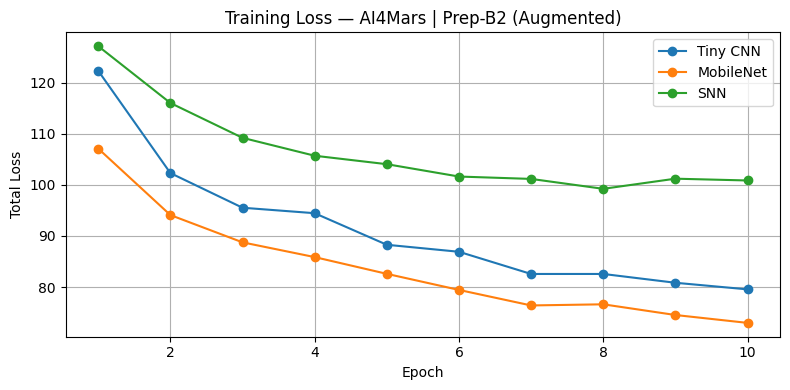

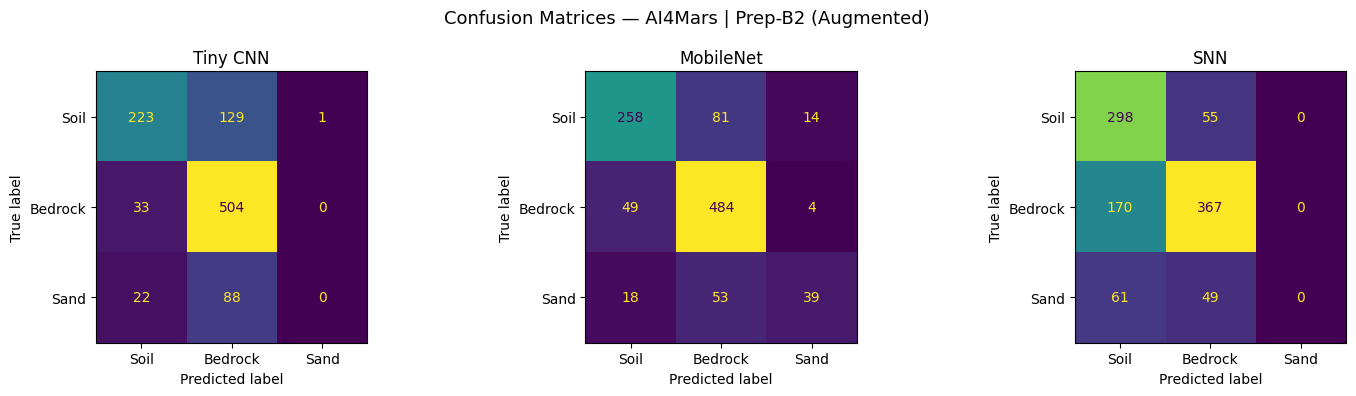

In [ ]:
lc4, cm4 = run_experiment(
    exp_name     = "AI4Mars | Prep-B2 (Augmented)",
    num_classes  = NUM_CLASSES_B,
    class_names  = CLASSES_B,
    train_loader = loader_train_b2,
    test_loader  = loader_test_b2,
    epochs       = 10
)

# 7. Results Summary

In [ ]:
df = pd.DataFrame(results)
df["Params (M)"] = (df["Params"] / 1e6).round(3)
print(df[["Experiment","Model","Accuracy (%)","Params (M)","Train Time (s)","Inference/img (ms)"]].to_string(index=False))

                       Experiment     Model  Accuracy (%)  Params (M)  Train Time (s)  Inference/img (ms)
  1000Samples | Prep-A1 (Minimal)  Tiny CNN         73.26       1.073           28.02              0.3669
  1000Samples | Prep-A1 (Minimal) MobileNet         71.12       2.227           63.00              0.9955
  1000Samples | Prep-A1 (Minimal)       SNN         66.84       2.136           58.79              1.6614
1000Samples | Prep-A2 (Augmented)  Tiny CNN         68.98       1.073           31.20              0.3759
1000Samples | Prep-A2 (Augmented) MobileNet         69.52       2.227           64.13              0.9750
1000Samples | Prep-A2 (Augmented)       SNN         58.82       2.136           61.68              1.7289
      AI4Mars | Prep-B1 (Minimal)  Tiny CNN         77.20       1.073          148.79              0.4146
      AI4Mars | Prep-B1 (Minimal) MobileNet         81.70       2.227          335.90              1.4721
      AI4Mars | Prep-B1 (Minimal)       SNN   

## Accuracy Comparison

/tmp/ipykernel_10883/3009965888.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(subset["Model"], rotation=15, ha='right')
/tmp/ipykernel_10883/3009965888.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(subset["Model"], rotation=15, ha='right')
/tmp/ipykernel_10883/3009965888.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(subset["Model"], rotation=15, ha='right')
/tmp/ipykernel_10883/3009965888.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(subset["Model"], rotation=15, ha='right')


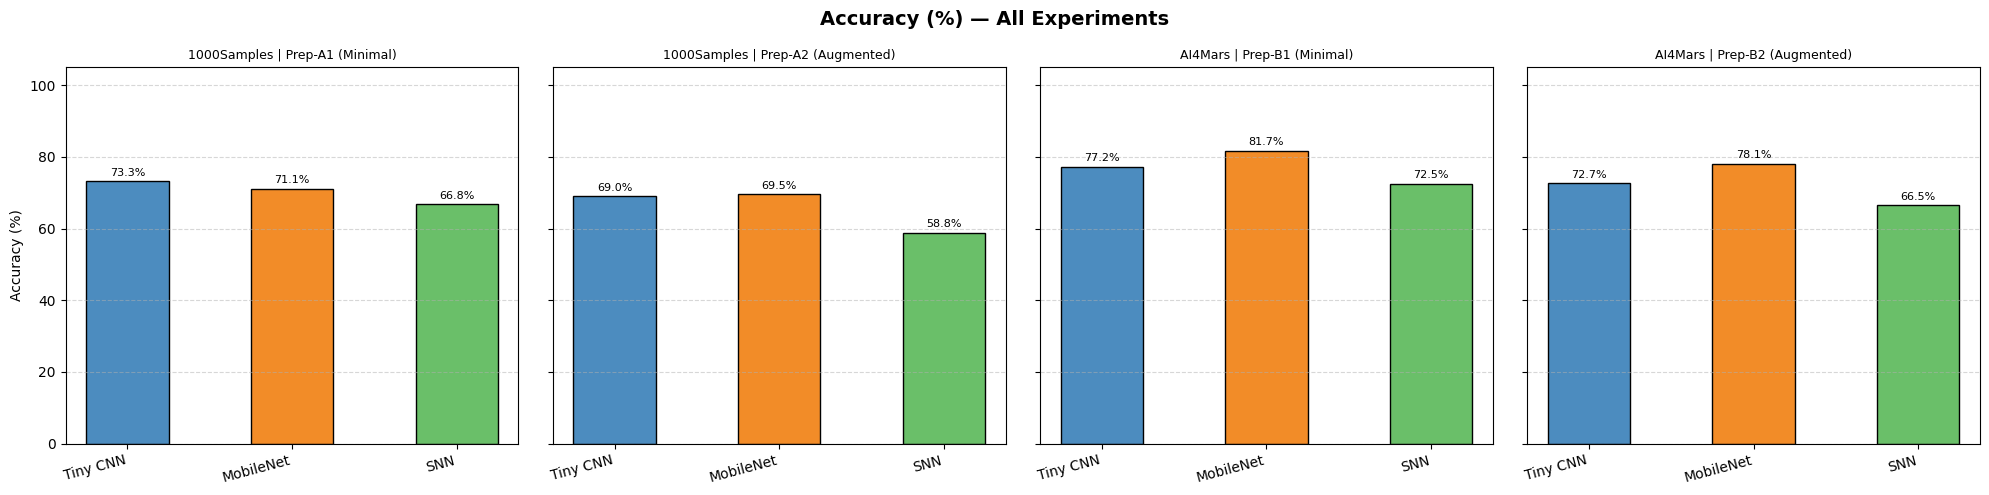

In [ ]:
COLORS = {"Tiny CNN": "#4C8CBF", "MobileNet": "#F28C28", "SNN": "#6ABF69"}
models_order = ["Tiny CNN", "MobileNet", "SNN"]
experiments  = df["Experiment"].unique()

fig, axes = plt.subplots(1, len(experiments), figsize=(5*len(experiments), 5), sharey=True)
fig.suptitle("Accuracy (%) — All Experiments", fontsize=14, fontweight='bold')

for ax, exp in zip(axes, experiments):
    subset = df[df["Experiment"] == exp]
    bars = ax.bar(subset["Model"], subset["Accuracy (%)"],
                  color=[COLORS[m] for m in subset["Model"]], width=0.5, edgecolor='black')
    ax.set_title(exp, fontsize=9)
    ax.set_ylabel("Accuracy (%)") if ax == axes[0] else None
    ax.set_ylim(0, 105)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    for bar, val in zip(bars, subset["Accuracy (%)"]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f"{val:.1f}%", ha='center', va='bottom', fontsize=8)
    ax.set_xticklabels(subset["Model"], rotation=15, ha='right')

plt.tight_layout()
plt.show()

## Model Size (Parameters)

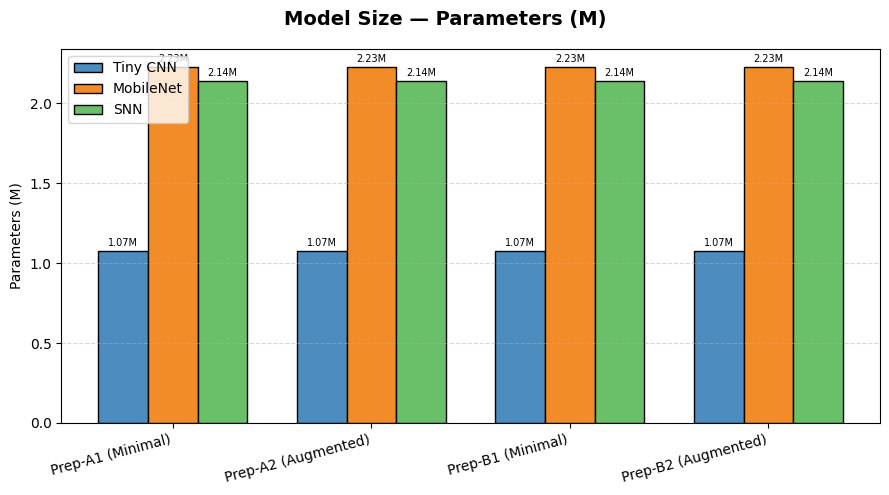

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
fig.suptitle("Model Size — Parameters (M)", fontsize=14, fontweight='bold')

x = np.arange(len(experiments))
width = 0.25
offsets = [-width, 0, width]

for offset, model_name in zip(offsets, models_order):
    vals = [df[(df["Experiment"]==exp) & (df["Model"]==model_name)]["Params (M)"].values[0]
            if len(df[(df["Experiment"]==exp) & (df["Model"]==model_name)]) > 0 else 0
            for exp in experiments]
    bars = ax.bar(x + offset, vals, width=width, label=model_name,
                  color=COLORS[model_name], edgecolor='black')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
                f"{v:.2f}M", ha='center', va='bottom', fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels([e.split("|")[1].strip() for e in experiments], rotation=15, ha='right')
ax.set_ylabel("Parameters (M)")
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Inference Speed (ms per image)

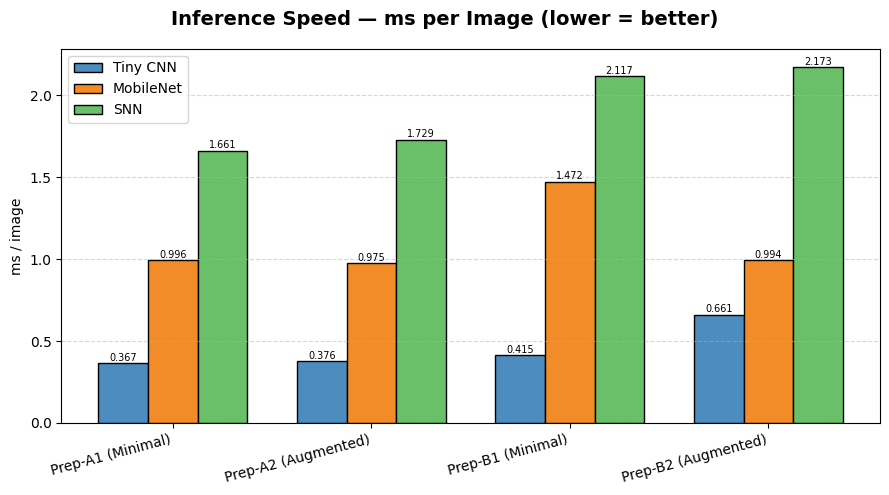

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
fig.suptitle("Inference Speed — ms per Image (lower = better)", fontsize=14, fontweight='bold')

for offset, model_name in zip(offsets, models_order):
    vals = [df[(df["Experiment"]==exp) & (df["Model"]==model_name)]["Inference/img (ms)"].values[0]
            if len(df[(df["Experiment"]==exp) & (df["Model"]==model_name)]) > 0 else 0
            for exp in experiments]
    bars = ax.bar(x + offset, vals, width=width, label=model_name,
                  color=COLORS[model_name], edgecolor='black')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
                f"{v:.3f}", ha='center', va='bottom', fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels([e.split("|")[1].strip() for e in experiments], rotation=15, ha='right')
ax.set_ylabel("ms / image")
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Preprocessing Impact: A1 vs A2 and B1 vs B2

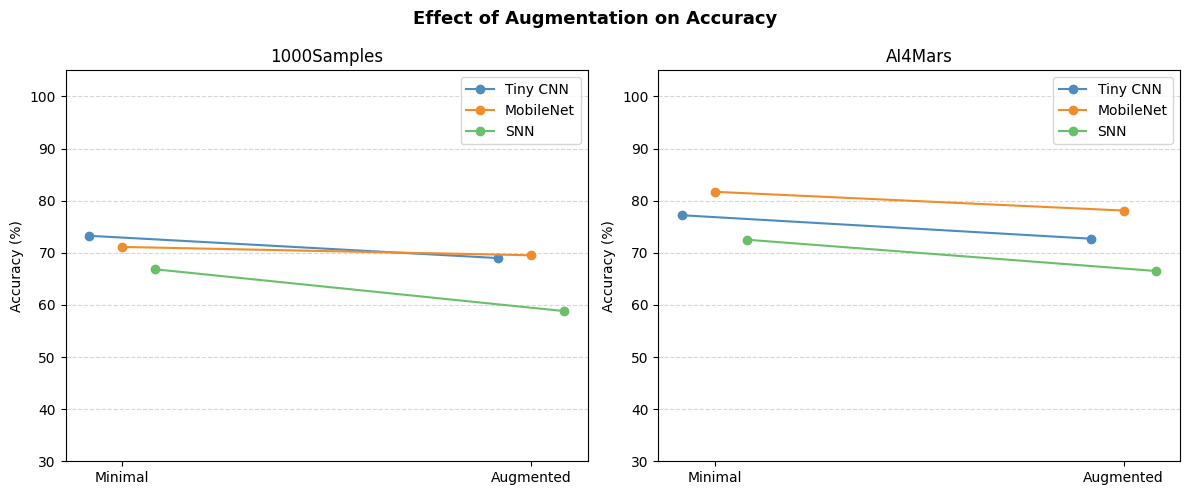

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Effect of Augmentation on Accuracy", fontsize=13, fontweight='bold')

for ax, (ds_label, e1, e2) in zip(axes, [
    ("1000Samples", "1000Samples | Prep-A1 (Minimal)", "1000Samples | Prep-A2 (Augmented)"),
    ("AI4Mars",     "AI4Mars | Prep-B1 (Minimal)",     "AI4Mars | Prep-B2 (Augmented)")
]):
    for i, model_name in enumerate(models_order):
        v1 = df[(df["Experiment"]==e1)&(df["Model"]==model_name)]["Accuracy (%)"].values
        v2 = df[(df["Experiment"]==e2)&(df["Model"]==model_name)]["Accuracy (%)"].values
        if len(v1) and len(v2):
            xs = [0 + i*0.08, 1 + i*0.08]
            ax.plot(xs, [v1[0], v2[0]], marker='o', label=model_name, color=list(COLORS.values())[i])
    ax.set_xticks([0.08, 1.08])
    ax.set_xticklabels(['Minimal', 'Augmented'])
    ax.set_title(ds_label)
    ax.set_ylabel("Accuracy (%)")
    ax.set_ylim(30, 105)
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## Final Summary Table

In [ ]:
print("\n" + "="*80)
print("FINAL RESULTS — Lightweight Terrain Classification for Rover Safety")
print("="*80)
summary = df[["Experiment","Model","Accuracy (%)","Params (M)","Train Time (s)","Inference/img (ms)"]]
summary = summary.sort_values(["Experiment","Accuracy (%)"], ascending=[True, False])
print(summary.to_string(index=False))
print("="*80)
print("\nKey Takeaways:")
best_acc = df.loc[df["Accuracy (%)"].idxmax()]
smallest = df.loc[df["Params"].idxmin()]
fastest  = df.loc[df["Inference/img (ms)"].idxmin()]
print(f"  Best Accuracy    : {best_acc['Model']} on {best_acc['Experiment']} → {best_acc['Accuracy (%)']}%")
print(f"  Smallest Model   : {smallest['Model']} → {smallest['Params (M)']}M parameters")
print(f"  Fastest Inference: {fastest['Model']} → {fastest['Inference/img (ms)']} ms/image")


FINAL RESULTS — Lightweight Terrain Classification for Rover Safety
                       Experiment     Model  Accuracy (%)  Params (M)  Train Time (s)  Inference/img (ms)
  1000Samples | Prep-A1 (Minimal)  Tiny CNN         73.26       1.073           28.02              0.3669
  1000Samples | Prep-A1 (Minimal) MobileNet         71.12       2.227           63.00              0.9955
  1000Samples | Prep-A1 (Minimal)       SNN         66.84       2.136           58.79              1.6614
1000Samples | Prep-A2 (Augmented) MobileNet         69.52       2.227           64.13              0.9750
1000Samples | Prep-A2 (Augmented)  Tiny CNN         68.98       1.073           31.20              0.3759
1000Samples | Prep-A2 (Augmented)       SNN         58.82       2.136           61.68              1.7289
      AI4Mars | Prep-B1 (Minimal) MobileNet         81.70       2.227          335.90              1.4721
      AI4Mars | Prep-B1 (Minimal)  Tiny CNN         77.20       1.073          148.

## Energy Consumption Analysis


In [ ]:
df_e = pd.DataFrame(energy_results)
print("Energy results collected:")
print(f"  Rows: {len(df_e)}  |  Experiments: {df_e['Experiment'].nunique()}")

mac_cols = [c for c in df_e.columns if c.startswith("MAC_")]
cc_cols  = [c for c in df_e.columns if c.startswith("CC_")]
print(f"  MAC columns  : {mac_cols}")
print(f"  CodeCarbon   : {cc_cols}")
print()
print(df_e[["Experiment","Model","MACs"] + cc_cols].to_string(index=False))

Energy results collected:
  Rows: 12  |  Experiments: 4
  MAC columns  : ['MAC_GPU (T4)_uJ', 'MAC_CPU_uJ', 'MAC_ARM_uJ', 'MAC_Loihi_uJ']
  CodeCarbon   : ['CC_nWh_per_img', 'CC_ugCO2_per_img']

                       Experiment     Model     MACs  CC_nWh_per_img  CC_ugCO2_per_img
  1000Samples | Prep-A1 (Minimal)  Tiny CNN 11191523        9.149954          2.612346
  1000Samples | Prep-A1 (Minimal) MobileNet 23896643       18.205312          5.197685
  1000Samples | Prep-A1 (Minimal)       SNN 58674091       28.981761          8.274401
1000Samples | Prep-A2 (Augmented)  Tiny CNN 11191523        6.742500          1.925009
1000Samples | Prep-A2 (Augmented) MobileNet 23896643       17.972982          5.131354
1000Samples | Prep-A2 (Augmented)       SNN 58674091       45.177048         12.898216
      AI4Mars | Prep-B1 (Minimal)  Tiny CNN 11191523        7.116260          2.031719
      AI4Mars | Prep-B1 (Minimal) MobileNet 23896643       26.038199          7.434003
      AI4Mars | Prep-B1

### Option 1: MAC-based Energy per Hardware Platform (μJ / inference)

/tmp/ipykernel_10883/1871801281.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(models_order, rotation=15, ha='right')
/tmp/ipykernel_10883/1871801281.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(models_order, rotation=15, ha='right')
/tmp/ipykernel_10883/1871801281.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(models_order, rotation=15, ha='right')
/tmp/ipykernel_10883/1871801281.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(models_order, rotation=15, ha='right')


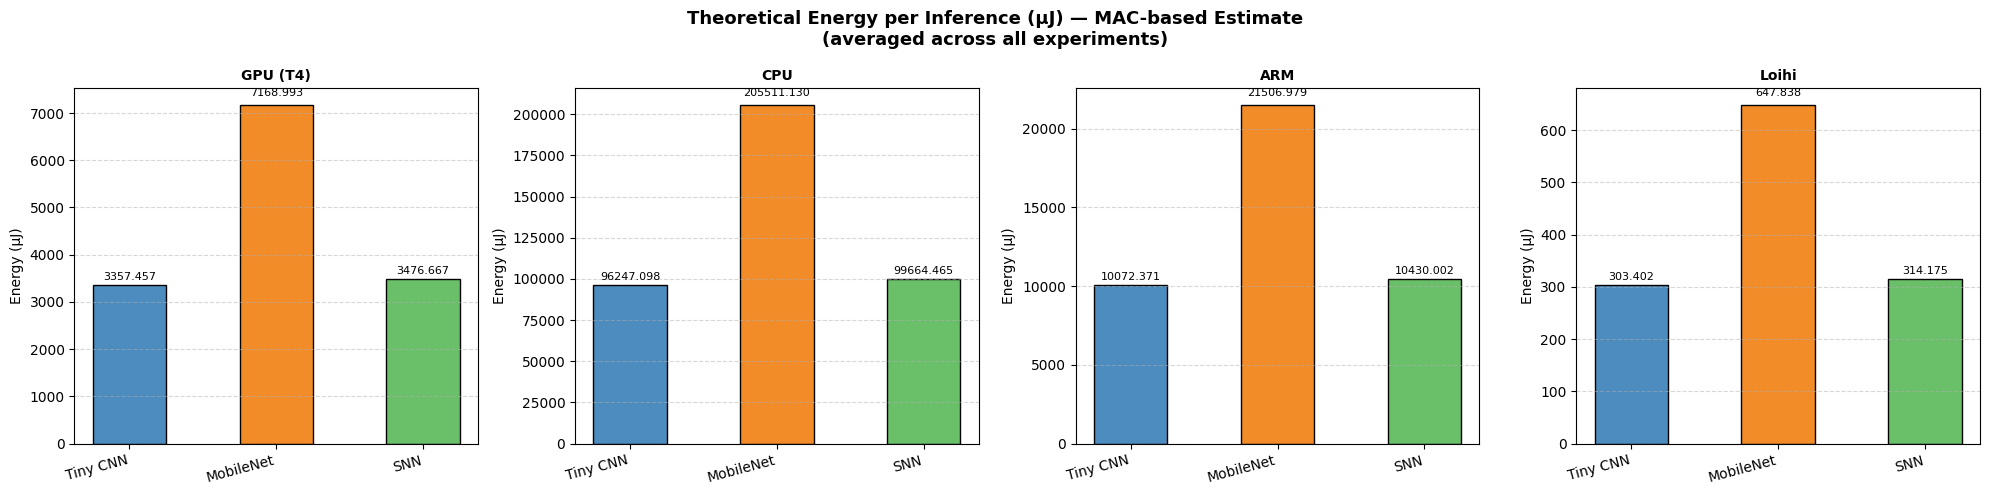

In [ ]:
COLORS = {"Tiny CNN": "#4C8CBF", "MobileNet": "#F28C28", "SNN": "#6ABF69"}
models_order = ["Tiny CNN", "MobileNet", "SNN"]
mac_cols     = [c for c in df_e.columns if c.startswith("MAC_")]
hw_labels    = [c.replace("MAC_","").replace("_uJ","") for c in mac_cols]

mean_energy = df_e.groupby("Model")[mac_cols].mean().reindex(models_order)

fig, axes = plt.subplots(1, len(mac_cols), figsize=(5*len(mac_cols), 5))
fig.suptitle("Theoretical Energy per Inference (μJ) — MAC-based Estimate\n"
             "(averaged across all experiments)", fontsize=13, fontweight='bold')

for ax, col, hw in zip(axes, mac_cols, hw_labels):
    vals  = mean_energy[col].values
    bars  = ax.bar(models_order, vals,
                   color=[COLORS[m] for m in models_order],
                   edgecolor='black', width=0.5)
    ax.set_title(hw, fontsize=10, fontweight='bold')
    ax.set_ylabel("Energy (μJ)")
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.02,
                f"{v:.3f}", ha='center', va='bottom', fontsize=8)
    ax.set_xticklabels(models_order, rotation=15, ha='right')

plt.tight_layout()
plt.show()

SNN Energy Advantage (relative to Tiny CNN = 1.0x):
  Hardware           TinyCNN    MobileNet      SNN   SNN Savings
  ------------------------------------------------------------
  GPU (T4)         3357.4569    7168.9929 3476.6674        -3.6%
  CPU             96247.0978  205511.1298 99664.4653        -3.6%
  ARM             10072.3707   21506.9787 10430.0022        -3.6%
  Loihi             303.4022     647.8380 314.1748        -3.6%


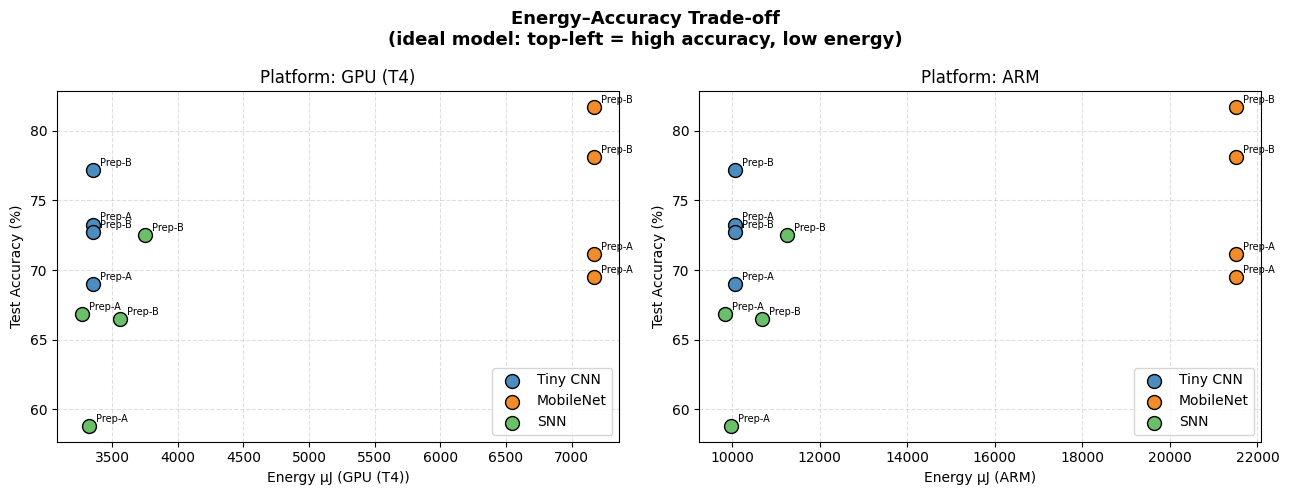

In [ ]:
print("SNN Energy Advantage (relative to Tiny CNN = 1.0x):")
print(f"  {'Hardware':<15} {'TinyCNN':>10} {'MobileNet':>12} {'SNN':>8} {'SNN Savings':>13}")
print(f"  {'-'*60}")

for col, hw in zip(mac_cols, hw_labels):
    cnn_e  = mean_energy.loc["Tiny CNN",   col]
    mob_e  = mean_energy.loc["MobileNet",  col]
    snn_e  = mean_energy.loc["SNN",        col]
    saving = (1 - snn_e/cnn_e) * 100
    print(f"  {hw:<15} {cnn_e:>10.4f} {mob_e:>12.4f} {snn_e:>8.4f} "
          f"{saving:>+11.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Energy–Accuracy Trade-off\n"
             "(ideal model: top-left = high accuracy, low energy)",
             fontsize=13, fontweight='bold')

for ax, (col, hw) in zip(axes, [
    (mac_cols[0], hw_labels[0]),
    (mac_cols[2], hw_labels[2]),
]):
    merged = df_e.merge(df[["Experiment","Model","Accuracy (%)"]])
    for model_name in models_order:
        sub = merged[merged["Model"] == model_name]
        ax.scatter(sub[col], sub["Accuracy (%)"],
                   label=model_name, color=COLORS[model_name],
                   s=100, edgecolors='black', zorder=3)
        for _, row in sub.iterrows():
            short = row["Experiment"].split("|")[1].strip()[:6]
            ax.annotate(short, (row[col], row["Accuracy (%)"]),
                        textcoords="offset points", xytext=(5,3), fontsize=7)
    ax.set_xlabel(f"Energy μJ ({hw})")
    ax.set_ylabel("Test Accuracy (%)")
    ax.set_title(f"Platform: {hw}")
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

### Option 2: CodeCarbon: Real Measured Energy

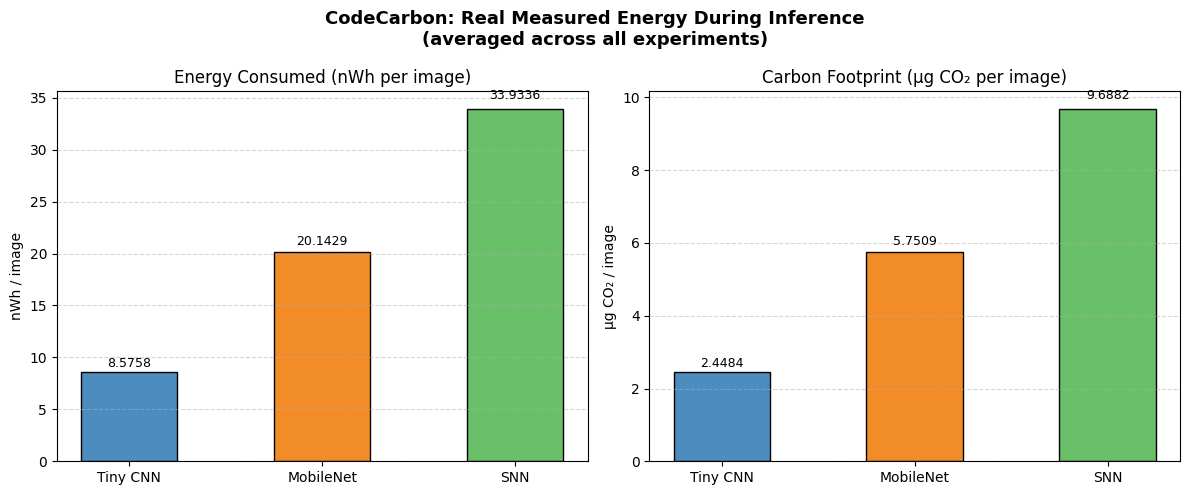


CodeCarbon Summary (mean across all experiments):
           CC_nWh_per_img  CC_ugCO2_per_img
Model                                      
Tiny CNN         8.575751          2.448409
MobileNet       20.142946          5.750887
SNN             33.933625          9.688177


In [ ]:
cc_mean = df_e.groupby("Model")[["CC_nWh_per_img","CC_ugCO2_per_img"]].mean().reindex(models_order)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("CodeCarbon: Real Measured Energy During Inference\n"
             "(averaged across all experiments)", fontsize=13, fontweight='bold')

ax = axes[0]
bars = ax.bar(models_order, cc_mean["CC_nWh_per_img"],
              color=[COLORS[m] for m in models_order], edgecolor='black', width=0.5)
ax.set_title("Energy Consumed (nWh per image)")
ax.set_ylabel("nWh / image")
ax.grid(axis='y', linestyle='--', alpha=0.5)
for bar, v in zip(bars, cc_mean["CC_nWh_per_img"]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.02,
            f"{v:.4f}", ha='center', va='bottom', fontsize=9)

ax = axes[1]
bars = ax.bar(models_order, cc_mean["CC_ugCO2_per_img"],
              color=[COLORS[m] for m in models_order], edgecolor='black', width=0.5)
ax.set_title("Carbon Footprint (μg CO₂ per image)")
ax.set_ylabel("μg CO₂ / image")
ax.grid(axis='y', linestyle='--', alpha=0.5)
for bar, v in zip(bars, cc_mean["CC_ugCO2_per_img"]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.02,
            f"{v:.4f}", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("\nCodeCarbon Summary (mean across all experiments):")
print(cc_mean.to_string())